# Addresses26 — HM Land Registry BN Price Paid Data Pipeline

This Colab notebook creates a Google Drive-backed repository similar in spirit to AirQuality26. It downloads HM Land Registry Price Paid Data, filters all `BN` postcodes, keeps **standard transactions only** (`PPD Category Type = A`), writes clean parquet/CSV outputs, and creates summary tables for larger analysis.

Official source: HM Land Registry Price Paid Data bulk CSVs.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import os, sys, json, time, math, hashlib, shutil, urllib.request
from datetime import datetime, timezone

PROJECT_NAME = "Addresses26"
DRIVE_ROOT = Path("/content/drive/MyDrive")
PROJECT_ROOT = DRIVE_ROOT / "Addresses26_Colab"
DATA_ROOT = DRIVE_ROOT / "Addresses26_Data"

RAW_DIR = DATA_ROOT / "raw" / "land_registry_price_paid"
DERIVED_DIR = DATA_ROOT / "derived" / "land_registry_price_paid"
REPORTS_DIR = PROJECT_ROOT / "reports"
MANIFEST_DIR = DATA_ROOT / "manifests"
CONFIG_DIR = PROJECT_ROOT / "configs"
NOTEBOOK_EXPORTS_DIR = PROJECT_ROOT / "exports"

for p in [PROJECT_ROOT, DATA_ROOT, RAW_DIR, DERIVED_DIR, REPORTS_DIR, MANIFEST_DIR, CONFIG_DIR, NOTEBOOK_EXPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RAW_DIR:", RAW_DIR)
print("DERIVED_DIR:", DERIVED_DIR)

PROJECT_ROOT: /content/drive/MyDrive/Addresses26_Colab
DATA_ROOT: /content/drive/MyDrive/Addresses26_Data
RAW_DIR: /content/drive/MyDrive/Addresses26_Data/raw/land_registry_price_paid
DERIVED_DIR: /content/drive/MyDrive/Addresses26_Data/derived/land_registry_price_paid


In [3]:
import pandas as pd
import numpy as np

try:
    import pyarrow
except Exception:
    !pip -q install pyarrow

PPD_COLUMNS = [
    "transaction_id",
    "price",
    "date_of_transfer",
    "postcode",
    "property_type",
    "old_new",
    "duration",
    "paon",
    "saon",
    "street",
    "locality",
    "town_city",
    "district",
    "county",
    "ppd_category_type",
    "record_status",
]

PROPERTY_TYPE_MAP = {
    "D": "Detached",
    "S": "Semi-detached",
    "T": "Terraced",
    "F": "Flat/Maisonette",
    "O": "Other",
}

OLD_NEW_MAP = {"Y": "New build", "N": "Established"}
DURATION_MAP = {"F": "Freehold", "L": "Leasehold", "U": "Unknown"}

def file_sha256(path: Path, block_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            h.update(block)
    return h.hexdigest()

def download_with_cache(url: str, out_path: Path, force=False):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if out_path.exists() and out_path.stat().st_size > 0 and not force:
        print("Cached:", out_path.name, f"{out_path.stat().st_size/1e6:.1f} MB")
        return out_path
    print("Downloading:", url)
    tmp = out_path.with_suffix(out_path.suffix + ".part")
    if tmp.exists():
        tmp.unlink()
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(out_path)
    print("Saved:", out_path.name, f"{out_path.stat().st_size/1e6:.1f} MB")
    return out_path

def clean_ppd_chunk(df):
    for c in ["postcode", "property_type", "old_new", "duration", "ppd_category_type", "record_status"]:
        df[c] = df[c].astype("string").str.strip().str.upper()
    for c in ["paon", "saon", "street", "locality", "town_city", "district", "county"]:
        df[c] = df[c].astype("string").str.strip()
    df["postcode"] = df["postcode"].str.replace(r"\s+", " ", regex=True)
    df["date_of_transfer"] = pd.to_datetime(df["date_of_transfer"], errors="coerce", utc=False)
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["postcode_area"] = df["postcode"].str.extract(r"^([A-Z]+)", expand=False)
    df["postcode_district"] = df["postcode"].str.extract(r"^([A-Z]+\\d+[A-Z]?)", expand=False)
    df["postcode_sector"] = df["postcode"].str.extract(r"^([A-Z]+\\d+[A-Z]?)\\s*(\\d)", expand=True).agg(lambda x: f"{x.iloc[0]} {x.iloc[1]}" if pd.notna(x.iloc[0]) and pd.notna(x.iloc[1]) else pd.NA, axis=1)
    df["property_type_label"] = df["property_type"].map(PROPERTY_TYPE_MAP).fillna(df["property_type"])
    df["old_new_label"] = df["old_new"].map(OLD_NEW_MAP).fillna(df["old_new"])
    df["duration_label"] = df["duration"].map(DURATION_MAP).fillna(df["duration"])
    df["address_compact"] = (
        df[["saon", "paon", "street", "locality", "town_city"]]
        .fillna("")
        .astype(str)
        .agg(lambda r: ", ".join([x for x in r if x and x != "<NA>"]), axis=1)
    )
    return df

In [4]:
CURRENT_YEAR = datetime.now().year

START_YEAR = 1995
END_YEAR = CURRENT_YEAR
POSTCODE_PREFIX = "BN"
STANDARD_ONLY = True
CHUNKSIZE = 250_000
FORCE_REDOWNLOAD = False

years = list(range(START_YEAR, END_YEAR + 1))
print("Years:", years[0], "to", years[-1], "|", len(years), "files")

Years: 1995 to 2026 | 32 files


In [5]:
def process_year(year: int):
    url = f"https://price-paid-data.publicdata.landregistry.gov.uk/pp-{year}.csv"
    raw_path = RAW_DIR / f"pp-{year}.csv"
    out_path = DERIVED_DIR / f"pp_bn_standard_{year}.parquet"
    manifest_path = MANIFEST_DIR / f"pp_bn_standard_{year}_manifest.json"

    download_with_cache(url, raw_path, force=FORCE_REDOWNLOAD)

    chunks = []
    total_rows = 0
    matched_rows = 0

    for chunk in pd.read_csv(
        raw_path,
        names=PPD_COLUMNS,
        header=None,
        dtype="string",
        chunksize=CHUNKSIZE,
        low_memory=False,
    ):
        total_rows += len(chunk)
        chunk = clean_ppd_chunk(chunk)
        mask = chunk["postcode"].str.startswith(POSTCODE_PREFIX, na=False)
        if STANDARD_ONLY:
            mask &= chunk["ppd_category_type"].eq("A")
        sub = chunk.loc[mask].copy()
        matched_rows += len(sub)
        if len(sub):
            chunks.append(sub)

    if chunks:
        out = pd.concat(chunks, ignore_index=True)
        out = out.drop_duplicates(subset=["transaction_id"]).sort_values(["date_of_transfer", "postcode", "price"])
    else:
        out = pd.DataFrame(columns=PPD_COLUMNS)

    out.to_parquet(out_path, index=False)

    manifest = {
        "year": year,
        "source_url": url,
        "raw_path": str(raw_path),
        "raw_size_bytes": raw_path.stat().st_size if raw_path.exists() else None,
        "raw_sha256": file_sha256(raw_path) if raw_path.exists() else None,
        "output_path": str(out_path),
        "total_rows_scanned": int(total_rows),
        "bn_standard_rows": int(matched_rows),
        "standard_only": STANDARD_ONLY,
        "postcode_prefix": POSTCODE_PREFIX,
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "attribution": "Contains HM Land Registry data © Crown copyright and database right. Licensed under the Open Government Licence v3.0.",
    }
    manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    print(year, "scanned:", total_rows, "BN standard:", matched_rows)
    return manifest

manifests = []
for y in years:
    try:
        manifests.append(process_year(y))
    except Exception as e:
        print("FAILED", y, repr(e))

manifest_df = pd.DataFrame(manifests)
manifest_df.to_csv(MANIFEST_DIR / "pp_bn_standard_manifest_index.csv", index=False)
manifest_df.tail()

Downloading: https://price-paid-data.publicdata.landregistry.gov.uk/pp-1995.csv
Saved: pp-1995.csv 139.4 MB
1995 scanned: 797124 BN standard: 15519
Downloading: https://price-paid-data.publicdata.landregistry.gov.uk/pp-1996.csv
Saved: pp-1996.csv 169.7 MB
1996 scanned: 965381 BN standard: 19739
Downloading: https://price-paid-data.publicdata.landregistry.gov.uk/pp-1997.csv
Saved: pp-1997.csv 192.7 MB
1997 scanned: 1094613 BN standard: 22627
Downloading: https://price-paid-data.publicdata.landregistry.gov.uk/pp-1998.csv
Saved: pp-1998.csv 185.3 MB
1998 scanned: 1050653 BN standard: 21502
Downloading: https://price-paid-data.publicdata.landregistry.gov.uk/pp-1999.csv
Saved: pp-1999.csv 204.4 MB
1999 scanned: 1195018 BN standard: 24806
Downloading: https://price-paid-data.publicdata.landregistry.gov.uk/pp-2000.csv
Saved: pp-2000.csv 193.4 MB
2000 scanned: 1129526 BN standard: 22028
Downloading: https://price-paid-data.publicdata.landregistry.gov.uk/pp-2001.csv
Saved: pp-2001.csv 220.3 MB


,year,source_url,raw_path,raw_size_bytes,raw_sha256,output_path,total_rows_scanned,bn_standard_rows,standard_only,postcode_prefix,created_utc,attribution
27,2022,https://price-paid-data.publicdata.landregistr...,/content/drive/MyDrive/Addresses26_Data/raw/la...,187616903,eb6909240c51f63a6c0f936e3119892ba5a0db39266688...,/content/drive/MyDrive/Addresses26_Data/derive...,1075584,14934,True,BN,2026-04-27T11:18:03.334873+00:00,Contains HM Land Registry data © Crown copyrig...
28,2023,https://price-paid-data.publicdata.landregistr...,/content/drive/MyDrive/Addresses26_Data/raw/la...,149946179,036c639a70bd62bb18036da4d1a099b82c7bd4a8753250...,/content/drive/MyDrive/Addresses26_Data/derive...,859145,11515,True,BN,2026-04-27T11:19:02.006826+00:00,Contains HM Land Registry data © Crown copyrig...
29,2024,https://price-paid-data.publicdata.landregistr...,/content/drive/MyDrive/Addresses26_Data/raw/la...,161058370,aa7dd89b04c3e1fc09c686db1b568904782fde8650da9c...,/content/drive/MyDrive/Addresses26_Data/derive...,923729,12532,True,BN,2026-04-27T11:19:58.023774+00:00,Contains HM Land Registry data © Crown copyrig...
30,2025,https://price-paid-data.publicdata.landregistr...,/content/drive/MyDrive/Addresses26_Data/raw/la...,139672841,94ba6fa20103c82783ded94ea484026180dfd424424988...,/content/drive/MyDrive/Addresses26_Data/derive...,802761,11425,True,BN,2026-04-27T11:20:50.844037+00:00,Contains HM Land Registry data © Crown copyrig...
31,2026,https://price-paid-data.publicdata.landregistr...,/content/drive/MyDrive/Addresses26_Data/raw/la...,9538063,a1a016fd8d2f9042dd6b4523bcab6af224d7672d80cb0d...,/content/drive/MyDrive/Addresses26_Data/derive...,54893,804,True,BN,2026-04-27T11:20:55.596262+00:00,Contains HM Land Registry data © Crown copyrig...


In [6]:
parquet_files = sorted(DERIVED_DIR.glob("pp_bn_standard_*.parquet"))
print("Parquet files:", len(parquet_files))

bn = pd.concat([pd.read_parquet(p) for p in parquet_files], ignore_index=True)
bn = bn.drop_duplicates(subset=["transaction_id"]).sort_values(["date_of_transfer", "postcode", "price"]).reset_index(drop=True)

all_out_parquet = DERIVED_DIR / "pp_bn_standard_all_years.parquet"
all_out_csv = DERIVED_DIR / "pp_bn_standard_all_years.csv"

bn.to_parquet(all_out_parquet, index=False)
bn.to_csv(all_out_csv, index=False)

print("Rows:", len(bn))
print("Date range:", bn["date_of_transfer"].min(), "to", bn["date_of_transfer"].max())
print("Outputs:")
print(all_out_parquet)
print(all_out_csv)

bn.head()

Parquet files: 32
Rows: 535781
Date range: 1995-01-02 00:00:00 to 2026-02-25 00:00:00
Outputs:
/content/drive/MyDrive/Addresses26_Data/derived/land_registry_price_paid/pp_bn_standard_all_years.parquet
/content/drive/MyDrive/Addresses26_Data/derived/land_registry_price_paid/pp_bn_standard_all_years.csv


,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,...,county,ppd_category_type,record_status,postcode_area,postcode_district,postcode_sector,property_type_label,old_new_label,duration_label,address_compact
0,{75E42F17-A6E8-4FC5-BA60-576388CAA756},30000,1995-01-02,BN1 6DJ,F,N,L,2,FLAT 7,FLORENCE ROAD,...,EAST SUSSEX,A,A,BN,<NA>,None,Flat/Maisonette,Established,Leasehold,"FLAT 7, 2, FLORENCE ROAD, BRIGHTON, BRIGHTON"
1,{CC94C6AF-87D8-4E78-A86B-B7E69B880706},78000,1995-01-03,BN1 3LD,T,N,F,23,<NA>,CROWN GARDENS,...,EAST SUSSEX,A,A,BN,<NA>,None,Terraced,Established,Freehold,"23, CROWN GARDENS, BRIGHTON, BRIGHTON"
2,{2A289EA0-0395-CDC8-E050-A8C063054829},72500,1995-01-03,BN1 4AQ,S,N,F,40,<NA>,GLOUCESTER ROAD,...,BRIGHTON AND HOVE,A,A,BN,<NA>,None,Semi-detached,Established,Freehold,"40, GLOUCESTER ROAD, BRIGHTON"
3,{2E813E5F-7919-4BAB-AA08-9DEB69DFE2AD},51000,1995-01-03,BN1 4EL,T,N,F,34,<NA>,TIDY STREET,...,EAST SUSSEX,A,A,BN,<NA>,None,Terraced,Established,Freehold,"34, TIDY STREET, BRIGHTON, BRIGHTON"
4,{C43E2279-3057-4AA6-A752-41D3D6F91FF5},52250,1995-01-03,BN10 7EE,S,N,F,14,<NA>,ST LAURENCE CLOSE,...,EAST SUSSEX,A,A,BN,<NA>,None,Semi-detached,Established,Freehold,"14, ST LAURENCE CLOSE, TELSCOMBE CLIFFS, PEACE..."


In [7]:
bn["year"] = bn["date_of_transfer"].dt.year
bn["month"] = bn["date_of_transfer"].dt.to_period("M").astype(str)

summary_by_year = (
    bn.groupby("year", dropna=False)
      .agg(
          transactions=("transaction_id", "nunique"),
          median_price=("price", "median"),
          mean_price=("price", "mean"),
          min_price=("price", "min"),
          max_price=("price", "max"),
      )
      .reset_index()
)

summary_by_district = (
    bn.groupby("postcode_district", dropna=False)
      .agg(
          transactions=("transaction_id", "nunique"),
          median_price=("price", "median"),
          mean_price=("price", "mean"),
          first_sale=("date_of_transfer", "min"),
          latest_sale=("date_of_transfer", "max"),
      )
      .sort_values(["transactions", "median_price"], ascending=[False, False])
      .reset_index()
)

summary_by_property_type = (
    bn.groupby(["year", "property_type_label"], dropna=False)
      .agg(transactions=("transaction_id", "nunique"), median_price=("price", "median"))
      .reset_index()
)

summary_by_year.to_csv(REPORTS_DIR / "summary_by_year.csv", index=False)
summary_by_district.to_csv(REPORTS_DIR / "summary_by_postcode_district.csv", index=False)
summary_by_property_type.to_csv(REPORTS_DIR / "summary_by_property_type_year.csv", index=False)

display(summary_by_year.tail(15))
display(summary_by_district.head(30))

,year,transactions,median_price,mean_price,min_price,max_price
17,2012,13158,220000.0,256029.398541,19700,2750000
18,2013,15135,225000.0,260688.566105,30000,3350000
19,2014,17433,245000.0,285626.079275,29000,3400000
20,2015,16724,265000.0,303256.861098,21500,2750000
21,2016,15928,283350.0,326557.722627,18000,4600000
22,2017,15001,300000.0,345187.732085,50000,6000000
23,2018,13872,309950.0,349998.182814,55000,4000000
24,2019,13340,310000.0,353018.591154,49000,2800000
25,2020,12138,325000.0,376444.629428,50000,3165000
26,2021,18279,350000.0,407420.608239,57750,5000000


,postcode_district,transactions,median_price,mean_price,first_sale,latest_sale
0,<NA>,535781,189000.0,231681.09802,1995-01-02,2026-02-25


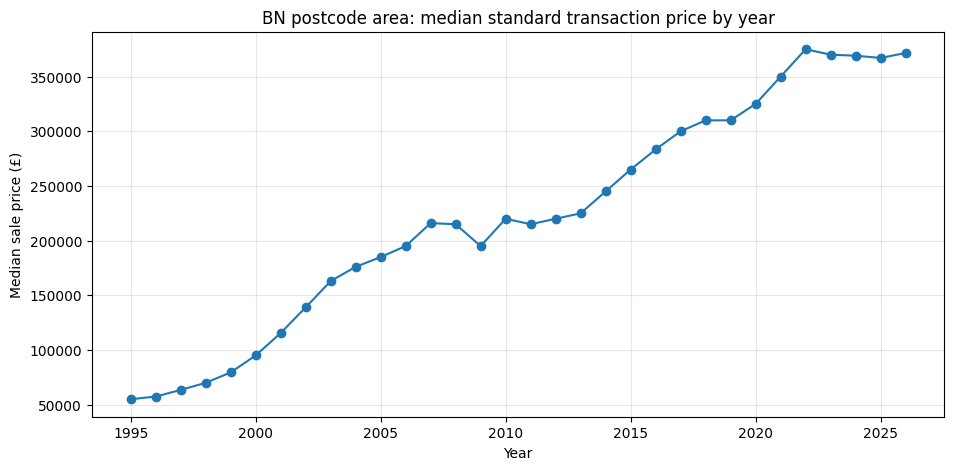

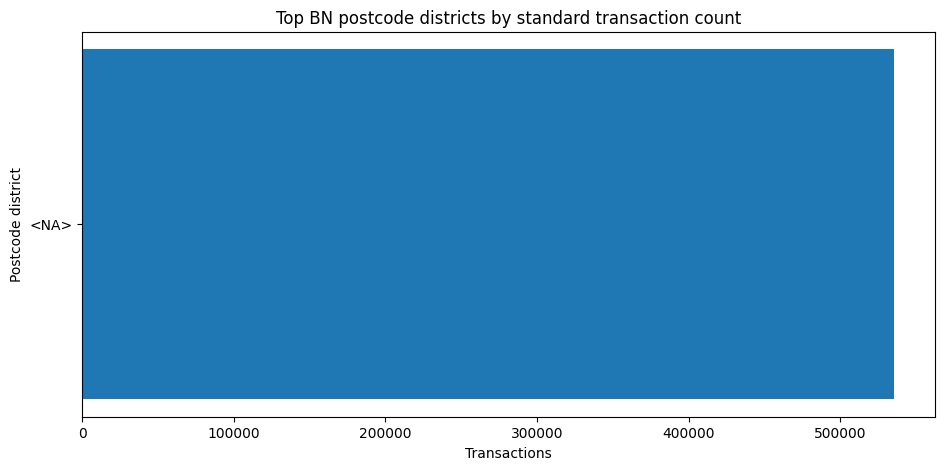

In [8]:
import matplotlib.pyplot as plt

annual = summary_by_year.dropna(subset=["year"]).copy()
annual["year"] = annual["year"].astype(int)

plt.figure(figsize=(11, 5))
plt.plot(annual["year"], annual["median_price"], marker="o")
plt.title("BN postcode area: median standard transaction price by year")
plt.xlabel("Year")
plt.ylabel("Median sale price (£)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(11, 5))
top_districts = summary_by_district.head(20).sort_values("transactions")
plt.barh(top_districts["postcode_district"].astype(str), top_districts["transactions"])
plt.title("Top BN postcode districts by standard transaction count")
plt.xlabel("Transactions")
plt.ylabel("Postcode district")
plt.show()

In [9]:
sample_path = Path("/content/drive/MyDrive/Addresses26_Colab/inputs/Addresses Sheet  (2025_09_24 10_47_56 UTC).xlsx")
if sample_path.exists():
    xl = pd.ExcelFile(sample_path)
    print("Workbook sheets:", xl.sheet_names)
    for sheet in xl.sheet_names:
        tmp = pd.read_excel(sample_path, sheet_name=sheet, nrows=10)
        print("\\n---", sheet, "---")
        display(tmp.head())
else:
    print("Optional: place your manually examined address workbook here to compare against the bulk pipeline:")
    print(sample_path)

Optional: place your manually examined address workbook here to compare against the bulk pipeline:
/content/drive/MyDrive/Addresses26_Colab/inputs/Addresses Sheet  (2025_09_24 10_47_56 UTC).xlsx


In [10]:
run_manifest = {
    "project": PROJECT_NAME,
    "run_utc": datetime.now(timezone.utc).isoformat(),
    "source": "HM Land Registry Price Paid Data yearly CSV files",
    "postcode_prefix": POSTCODE_PREFIX,
    "standard_only": STANDARD_ONLY,
    "rows": int(len(bn)),
    "outputs": {
        "all_years_parquet": str(all_out_parquet),
        "all_years_csv": str(all_out_csv),
        "summary_by_year": str(REPORTS_DIR / "summary_by_year.csv"),
        "summary_by_postcode_district": str(REPORTS_DIR / "summary_by_postcode_district.csv"),
        "summary_by_property_type_year": str(REPORTS_DIR / "summary_by_property_type_year.csv"),
        "manifest_index": str(MANIFEST_DIR / "pp_bn_standard_manifest_index.csv"),
    },
    "attribution": "Contains HM Land Registry data © Crown copyright and database right. Licensed under the Open Government Licence v3.0.",
}
(PROJECT_ROOT / "run_manifest.json").write_text(json.dumps(run_manifest, indent=2), encoding="utf-8")
print(json.dumps(run_manifest, indent=2))

{
  "project": "Addresses26",
  "run_utc": "2026-04-27T11:21:06.781409+00:00",
  "source": "HM Land Registry Price Paid Data yearly CSV files",
  "postcode_prefix": "BN",
  "standard_only": true,
  "rows": 535781,
  "outputs": {
    "all_years_parquet": "/content/drive/MyDrive/Addresses26_Data/derived/land_registry_price_paid/pp_bn_standard_all_years.parquet",
    "all_years_csv": "/content/drive/MyDrive/Addresses26_Data/derived/land_registry_price_paid/pp_bn_standard_all_years.csv",
    "summary_by_year": "/content/drive/MyDrive/Addresses26_Colab/reports/summary_by_year.csv",
    "summary_by_postcode_district": "/content/drive/MyDrive/Addresses26_Colab/reports/summary_by_postcode_district.csv",
    "summary_by_property_type_year": "/content/drive/MyDrive/Addresses26_Colab/reports/summary_by_property_type_year.csv",
    "manifest_index": "/content/drive/MyDrive/Addresses26_Data/manifests/pp_bn_standard_manifest_index.csv"
  },
  "attribution": "Contains HM Land Registry data \u00a9 Cro